# WM 2026 Match Predictor – Analyse & Modell-Demo

Datenpipeline-Status, Feature-Übersicht, Modell-Evaluation und eine Live-Demo:
zwei Teams eingeben, das Modell sagt Sieg-Wahrscheinlichkeit UND erwartetes Ergebnis voraus.

Voraussetzung: `fetch_data.py`, `build_features.py`, `train_models.py` bereits ausgeführt.


#### Datenquellen

| Quelle | Speicherort | Inhalt |
|---|---|---|
| API-Football | `data/raw/fixtures_*.json` | Länderspiele 2018–2026 pro Team |
| API-Football | `data/raw/stats/{id}.json` | Ballbesitz, Schüsse, Ecken pro Spiel |
| Kaggle Elo Ratings | `data/raw/elo_ratings_wc2026.csv` | Ranking pro Team/Jahr, 1901–2026 |
| `build_features.py` | `data/processed/match_features.csv` | Feature-Tabelle (1 Zeile/Spiel) |
| `train_models.py` | `models/*.pkl`, `*_feature_columns.json` | Klassifikator + Tore-Regressor |

#### Features

Alle Features nur aus Daten **vor** dem Spieldatum (kein Leakage). `a_*`/`b_*` = Team A/B.

| Kategorie | Spalten | Bedeutung |
|---|---|---|
| Meta | `fixture_id`, `date`, `team_a/b`, `result` | Identifikatoren + Zielvariable (A/Draw/B) |
| Form (Ø letzte 5 Spiele) | `*_form_points`, `*_goals_for_avg`, `*_goals_against_avg` | Punkte, Tore, Gegentore |
| Match-Stats (Ø letzte 5) | `*_possession_avg`, `*_shots_total_avg`, `*_shots_on_goal_avg`, `*_corners_avg` | Ballbesitz, Schüsse, Ecken |
| H2H | `h2h_games`, `h2h_a_wins/draws/losses` | Direkter Vergleich A vs. B |
| Ranking | `ranking_a`, `ranking_b`, `ranking_diff` | Team-Stärke im Spieljahr (stärkstes Feature) |

`goals_a`/`goals_b` = Ist-Ergebnis, nur zur Kontrolle – kein Klassifikations-Feature
(sind die Zielgrösse des Tore-Regressors).

---

### **1) Setup**

In [1]:
import sys
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    mean_absolute_error, mean_squared_error,
)
from sklearn.dummy import DummyClassifier
from IPython.display import display

sys.path.insert(0, str(Path.cwd().parent / "src"))
from config import DATA_RAW_DIR, DATA_PROCESSED_DIR, PROJECT_ROOT, WM2026_TEAMS

STATS_DIR = DATA_RAW_DIR / "stats"
FEATURES_FILE = DATA_PROCESSED_DIR / "match_features.csv"
MODELS_DIR = PROJECT_ROOT / "models"

pd.set_option("display.max_columns", None)


def _read_json_robust(path: Path):
    """Liest JSON ein, mit Fallback auf cp1252 (ältere Dateien vor Encoding-Fix)."""
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except UnicodeDecodeError:
        return json.loads(path.read_text(encoding="cp1252"))

---

### **2) Datenpipeline-Status**
Fixtures- und Match-Stats-Fortschritt pro Team, plus Abdeckung der einzelnen Statistik-Typen.

In [2]:
def analyze_data_status():
    stats_files = list(STATS_DIR.glob("*.json"))
    existing_stats_ids = {int(f.stem) for f in stats_files if f.stem.isdigit()}

    team_rows = []
    total_fixtures = 0
    total_unique_ids = set()

    for fifa_name in WM2026_TEAMS:
        fixtures_file = DATA_RAW_DIR / f"fixtures_{fifa_name.replace(' ', '_')}.json"
        if not fixtures_file.exists():
            team_rows.append((fifa_name, "FEHLT", "-", "-", "\u274c"))
            continue
        if fixtures_file.stat().st_size == 0:
            team_rows.append((fifa_name, "LEER", "-", "-", "\u26a0\ufe0f"))
            continue
        try:
            fixtures = _read_json_robust(fixtures_file)
        except (json.JSONDecodeError, UnicodeDecodeError):
            team_rows.append((fifa_name, "KAPUTT", "-", "-", "\u274c"))
            continue

        fixture_ids = [fx.get("fixture", {}).get("id") for fx in fixtures]
        fixture_ids = [fid for fid in fixture_ids if fid is not None]
        n_games = len(fixture_ids)
        n_stats_done = sum(fid in existing_stats_ids for fid in fixture_ids)
        progress = 100 * n_stats_done / n_games if n_games > 0 else 0
        status = "\u2705" if progress == 100 else ("\U0001f7e1" if progress > 0 else "\u26aa")

        team_rows.append((fifa_name, str(n_games), str(n_stats_done), f"{progress:.0f}%", status))
        total_fixtures += n_games
        total_unique_ids.update(fixture_ids)

    available_stats_ids = existing_stats_ids & total_unique_ids
    overall_progress = 100 * len(available_stats_ids) / len(total_unique_ids) if total_unique_ids else 0
    valid_teams = sum(row[1] not in ("FEHLT", "LEER", "KAPUTT") for row in team_rows)
    problem_teams = [row[0] for row in team_rows if row[1] in ("FEHLT", "LEER", "KAPUTT")]

    print(f"Teams komplett abgerufen : {valid_teams} / {len(WM2026_TEAMS)}")
    print(f"Eindeutige Fixtures      : {len(total_unique_ids)}")
    print(f"Match-Stats vorhanden    : {len(available_stats_ids)} / {len(total_unique_ids)} ({overall_progress:.1f}%)")
    if problem_teams:
        print(f"\nProblematische Teams: {problem_teams}")
    else:
        print("\n\u2705 Alle Fixture-Dateien vorhanden und lesbar.")


analyze_data_status()

Teams komplett abgerufen : 48 / 48
Eindeutige Fixtures      : 4687
Match-Stats vorhanden    : 4687 / 4687 (100.0%)

✅ Alle Fixture-Dateien vorhanden und lesbar.


---

### **3) Feature-Tabelle laden & Sanity-Check**
Überblick, Heim/Auswärts-Verteilung, fehlende Werte, Beispielzeilen.

In [3]:
df = pd.read_csv(FEATURES_FILE)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df["a_is_home"] = df["a_is_home"].astype(bool)

print(f"Shape: {df.shape} | Zeitraum: {df['date'].min().date()} bis {df['date'].max().date()}\n")

n = len(df)
home_win = (df["a_is_home"] & (df["result"] == "A")) | (~df["a_is_home"] & (df["result"] == "B"))
away_win = (df["a_is_home"] & (df["result"] == "B")) | (~df["a_is_home"] & (df["result"] == "A"))
draw = df["result"] == "Draw"
print("Heim/Auswärts-Verteilung:")
for label, mask in [("Heimsieg", home_win), ("Unentschieden", draw), ("Auswärtssieg", away_win)]:
    v = int(mask.sum())
    print(f"  {label:<16} {v:>5}  ({100 * v / n:5.1f}%)")

missing_possession = (df["a_possession_avg"].isna() | df["b_possession_avg"].isna()).sum()
missing_ranking = df["ranking_diff"].isna().sum()
print(f"\nSpiele ohne Ballbesitz-Daten : {missing_possession:>5}  ({100 * missing_possession / n:5.1f}%)")
print(f"Spiele ohne Ranking-Differenz: {missing_ranking:>5}  ({100 * missing_ranking / n:5.1f}%)")

print("\nBeispielzeilen:")
display(df[["date", "team_a", "team_b", "a_is_home", "goals_a", "goals_b", "result", "ranking_diff"]].head(3))

Shape: (1141, 31) | Zeitraum: 2015-10-08 bis 2026-06-18

Heim/Auswärts-Verteilung:
  Heimsieg           520  ( 45.6%)
  Unentschieden      307  ( 26.9%)
  Auswärtssieg       314  ( 27.5%)

Spiele ohne Ballbesitz-Daten :    60  (  5.3%)
Spiele ohne Ranking-Differenz:     0  (  0.0%)

Beispielzeilen:


,date,team_a,team_b,a_is_home,goals_a,goals_b,result,ranking_diff
0,2015-10-08,Australia,Jordan,False,0,2,B,173.0
1,2015-10-13,Colombia,Uruguay,False,0,3,B,8.0
2,2015-10-14,Argentina,Paraguay,False,0,0,Draw,296.0


---

### **4) Explorative Analyse**
Feature-Verteilung nach Ergebnis (zeigt, ob Ranking-Differenz und Formkurve mit dem Ausgang zusammenhängen)
sowie die stärksten paarweisen Korrelationen.

Getestete Features: 23
                      F_stat  p_value
ranking_diff         178.580    0.000
ranking_a             54.979    0.000
ranking_b             47.814    0.000
b_possession_avg      20.294    0.000
a_possession_avg      18.173    0.000
a_goals_for_avg       16.795    0.000
b_shots_on_goal_avg   16.205    0.000
a_form_points         15.132    0.000
a_goals_against_avg   14.740    0.000
a_shots_on_goal_avg   14.714    0.000
b_form_points         13.990    0.000
b_goals_against_avg   11.623    0.000
b_shots_total_avg     11.535    0.000
a_shots_total_avg     11.402    0.000
b_goals_for_avg       10.821    0.000
h2h_a_wins             8.353    0.000
b_corners_avg          6.426    0.002
a_corners_avg          6.226    0.002
h2h_games              4.065    0.017
b_form_games_count     3.179    0.042
h2h_a_draws            1.455    0.234
a_form_games_count     1.138    0.321
h2h_a_losses           0.064    0.938

20 von 23 Features signifikant (p<0.05)


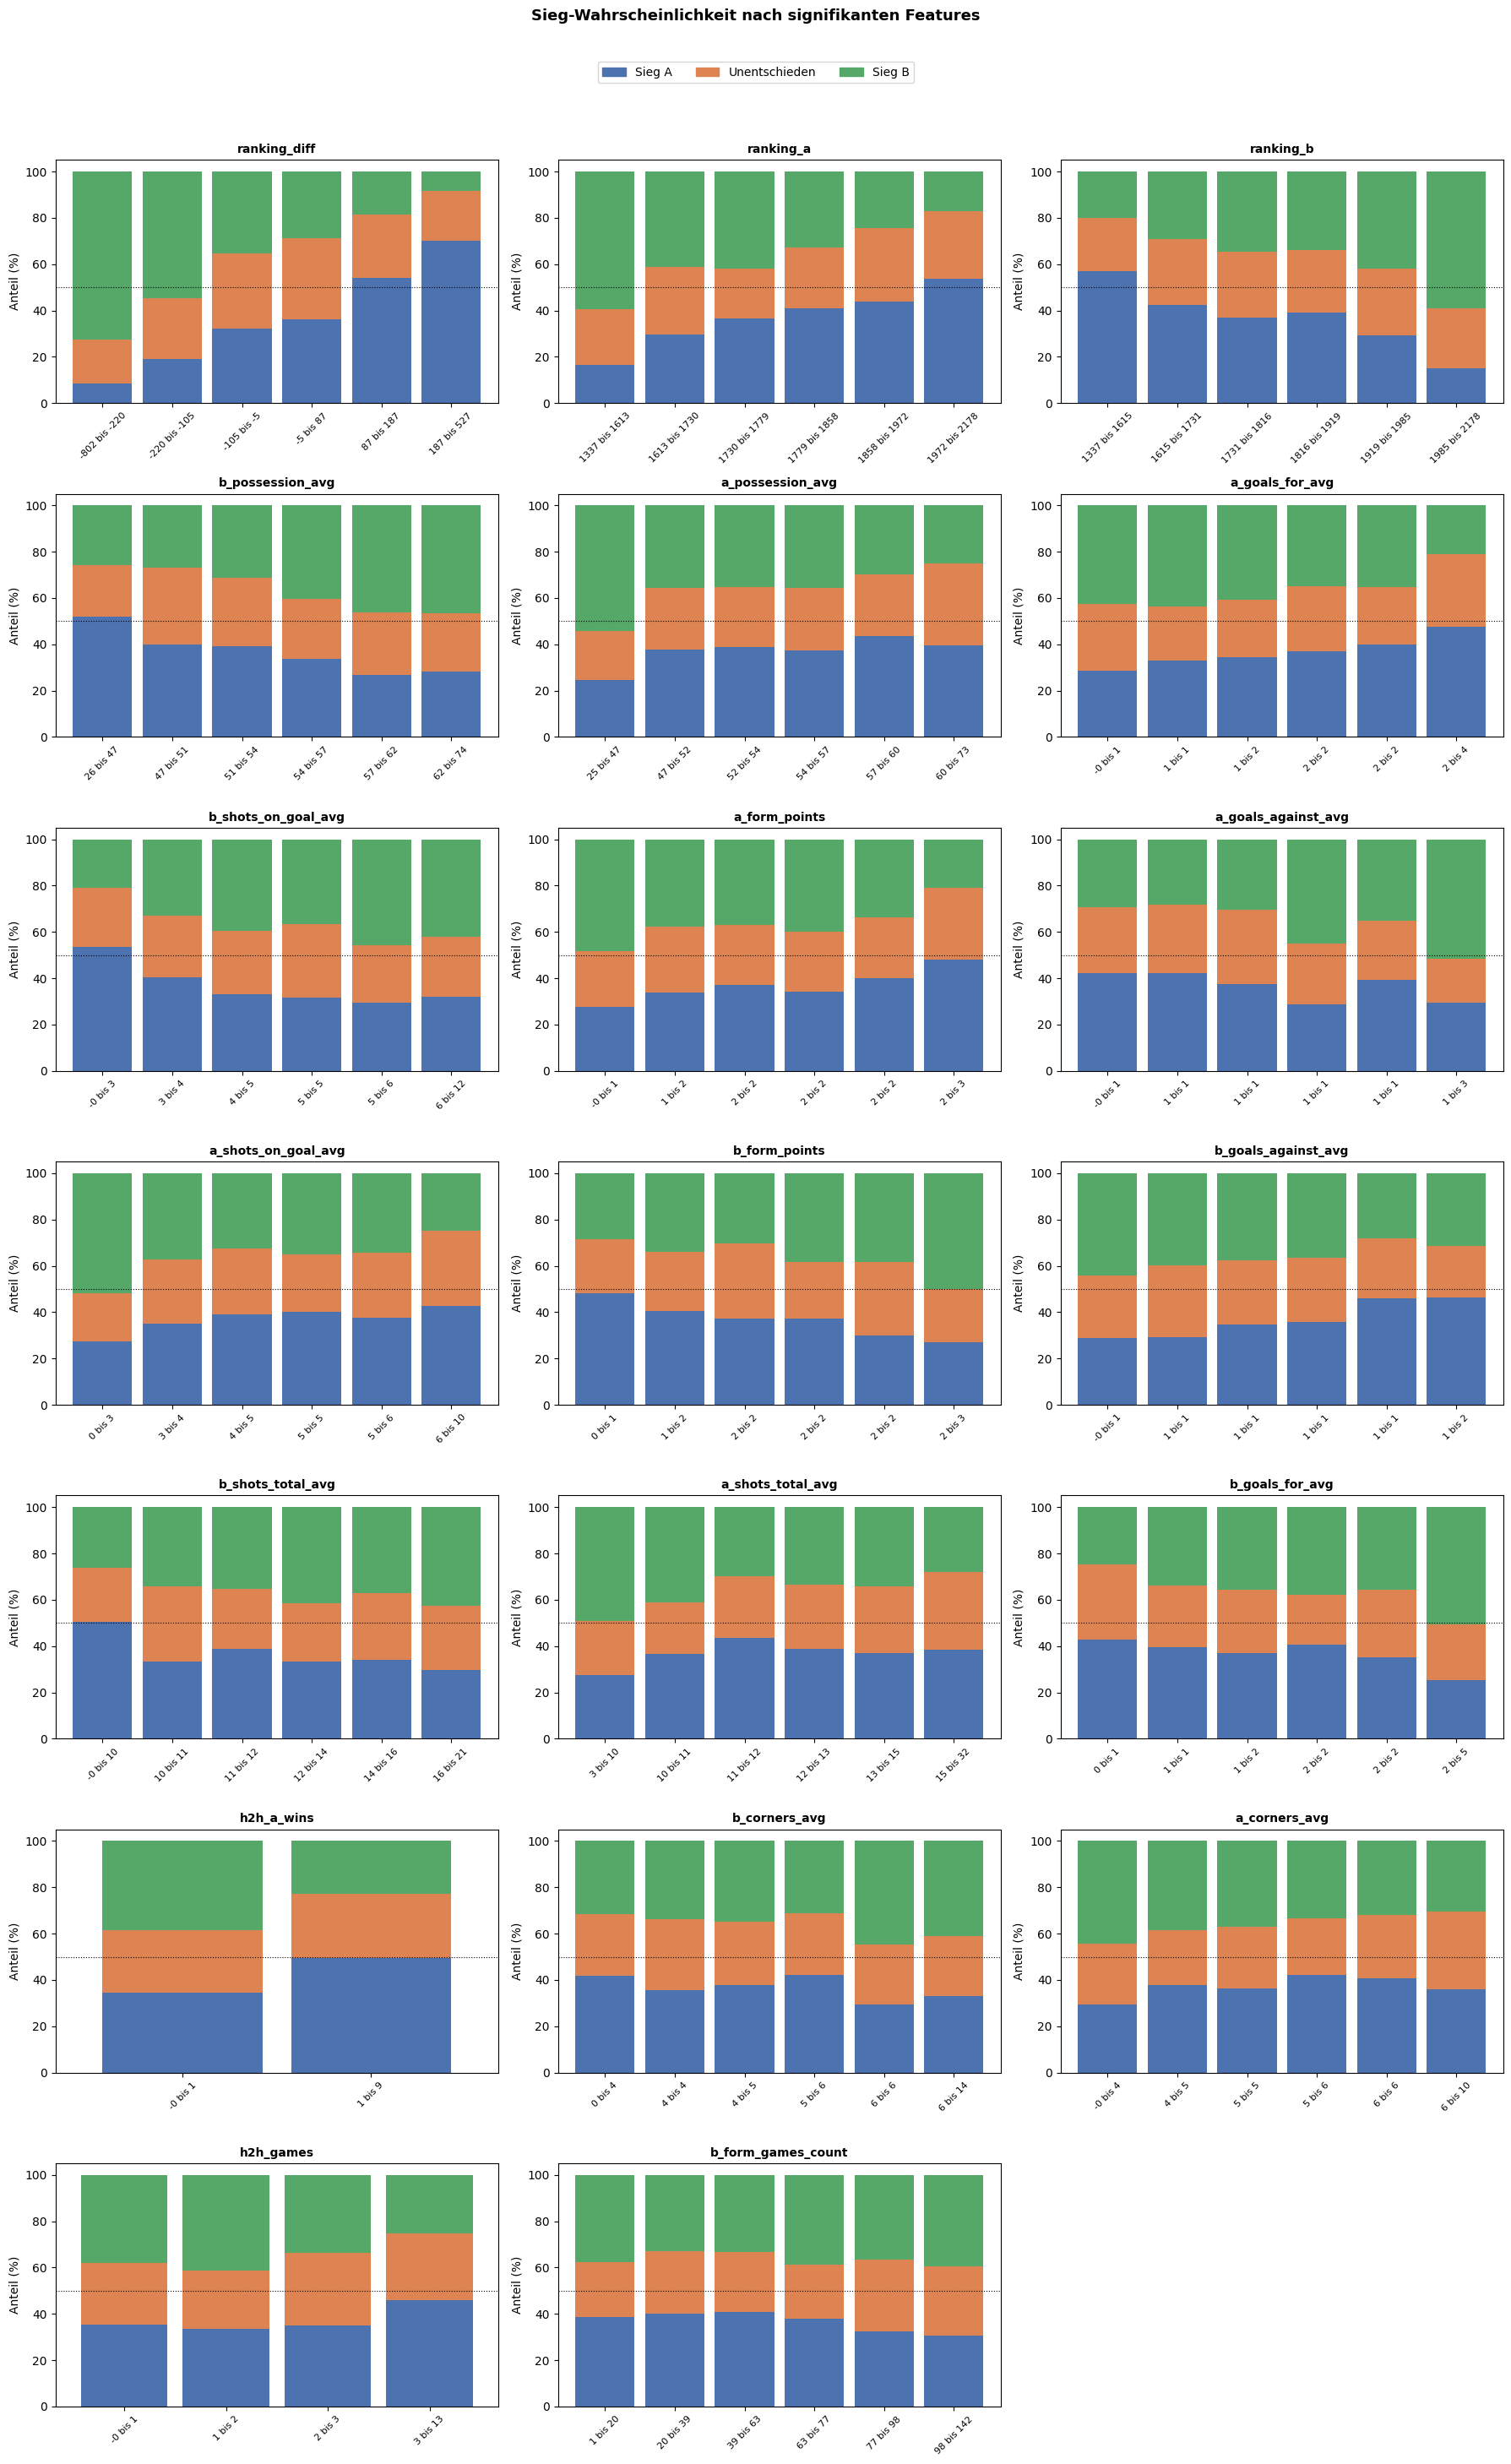

In [4]:
from scipy.stats import f_oneway

def separation_score(df, col):
    """F-Wert: Trennschärfe zwischen Sieg A / Draw / Sieg B, modellunabhängig."""
    groups = [df.loc[df["result"] == r, col].dropna() for r in ["A", "Draw", "B"]]
    return f_oneway(*groups)


def plot_outcome_by_feature(df, col, ax, n_bins=6):
    try:
        binned = pd.qcut(df[col], q=n_bins, duplicates="drop")
    except ValueError:
        binned = pd.cut(df[col], bins=n_bins)
    pct = (df.groupby(binned, observed=True)["result"].value_counts(normalize=True)
           .unstack().reindex(columns=["A", "Draw", "B"]).fillna(0) * 100)
    pct.index = [f"{iv.left:.0f} bis {iv.right:.0f}" for iv in pct.index]
    pct.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#DD8452", "#55A868"], width=0.85, legend=False)
    ax.axhline(50, color="black", linewidth=0.8, linestyle=":")
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Anteil (%)")
    ax.tick_params(axis="x", rotation=45, labelsize=8)


numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ("fixture_id", "goals_a", "goals_b") and df[c].nunique() > 1]

scores = {col: separation_score(df, col) for col in numeric_cols}
scores_df = pd.DataFrame(scores, index=["F_stat", "p_value"]).T.sort_values("F_stat", ascending=False)
print(f"Getestete Features: {len(scores_df)}\n{scores_df.round(3)}")

significant = scores_df.query("p_value < 0.05").index.tolist()
print(f"\n{len(significant)} von {len(scores_df)} Features signifikant (p<0.05)")

n_cols = 3
n_rows = int(np.ceil(len(significant) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)
for ax, col in zip(axes.flat, significant):
    plot_outcome_by_feature(df, col, ax)
for ax in axes.flat[len(significant):]:
    ax.axis("off")

fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in ["#4C72B0", "#DD8452", "#55A868"]],
           labels=["Sieg A", "Unentschieden", "Sieg B"], loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Sieg-Wahrscheinlichkeit nach signifikanten Features", fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

---

### **5) Model Evaluation**
Beide Modelle werden auf demselben **chronologischen 80/20-Split** evaluiert. So wird verhindert, dass zukünftige Spiele zum Training früherer Vorhersagen verwendet werden.

Für beide Modelle wird zusätzlich eine einfache Baseline berechnet. Dadurch ist ersichtlich, ob das trainierte Modell einen tatsächlichen Mehrwert gegenüber einer trivialen Vorhersage liefert.

#### **5.1 Modell 1: Klassifikator**
Vorhersage der Klassen **Sieg Team A**, **Unentschieden** und **Sieg Team B**. Bewertet werden Accuracy, Macro-F1, Classification Report, Confusion Matrix und Feature Importances.

---------------------------------------------
Chronologischer Train-Test-Split
---------------------------------------------
Training:        912 Spiele | 2015-10-08 bis 2024-10-10
Test:            229 Spiele | 2024-10-11 bis 2026-06-18

---------------------------------------------
Modellvergleich
---------------------------------------------

Modell                       Accuracy    Macro-F1
-------------------------------------------------
Random Forest                   0.498       0.456
Baseline                        0.354       0.174

----------------------------
Classification Report
----------------------------
              precision    recall  f1-score   support

      A Sieg       0.54      0.49      0.52        81
        Draw       0.35      0.17      0.23        69
      B Sieg       0.51      0.78      0.62        79

    accuracy                           0.50       229
   macro avg       0.47      0.48      0.46       229
weighted avg       0.47      0.50      0.47   

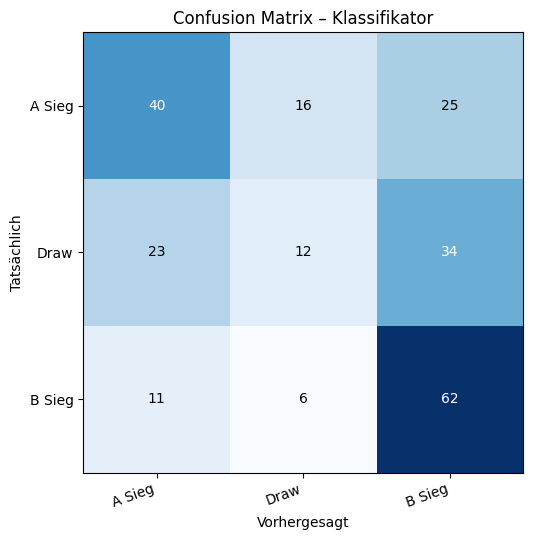


---------------------------------------------
Top 10 wichtigste Features (Klassifikator)
---------------------------------------------

Feature                         Importance
------------------------------------------
ranking_diff                         0.127
ranking_a                            0.068
ranking_b                            0.067
b_shots_on_goal_avg                  0.047
b_possession_avg                     0.047
a_possession_avg                     0.046
b_goals_against_avg                  0.044
a_form_points                        0.044
a_goals_against_avg                  0.042
b_form_points                        0.042


In [5]:
clf_model = joblib.load(MODELS_DIR / "random_forest_model.pkl")
clf_imputer = joblib.load(MODELS_DIR / "imputer.pkl")
clf_feature_cols = json.loads(
    (MODELS_DIR / "feature_columns.json").read_text(encoding="utf-8")
)

# Chronologischer 80/20-Split
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print("---------------------------------------------")
print("Chronologischer Train-Test-Split")
print("---------------------------------------------")
print(f"{'Training:':<14} {len(train_df):>5} Spiele | {train_df['date'].min().date()} bis {train_df['date'].max().date()}")
print(f"{'Test:':<14} {len(test_df):>5} Spiele | {test_df['date'].min().date()} bis {test_df['date'].max().date()}")

X_test = test_df[clf_feature_cols]
y_test = test_df["result"]
X_test_imp = clf_imputer.transform(X_test)
y_pred = clf_model.predict(X_test_imp)

# Baseline: immer die im Training häufigste Klasse vorhersagen
X_train = train_df[clf_feature_cols]
y_train = train_df["result"]
X_train_imp = clf_imputer.transform(X_train)

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train_imp, y_train)
y_dummy = dummy_clf.predict(X_test_imp)

print()
print("---------------------------------------------")
print("Modellvergleich")
print("---------------------------------------------")
print()
print(f"{'Modell':<25}{'Accuracy':>12}{'Macro-F1':>12}")
print("-" * 49)
print(f"{'Random Forest':<25}{accuracy_score(y_test, y_pred):>12.3f}{f1_score(y_test, y_pred, average='macro'):>12.3f}")
print(f"{'Baseline':<25}{accuracy_score(y_test, y_dummy):>12.3f}{f1_score(y_test, y_dummy, average='macro'):>12.3f}")

labels = ["A", "Draw", "B"]
display_labels = [
    "A Sieg",
    "Draw",
    "B Sieg",
]

print()
print("----------------------------")
print("Classification Report")
print("----------------------------")
print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=display_labels,
    zero_division=0,
))

cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(display_labels, rotation=20, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(display_labels)
ax.set_xlabel("Vorhergesagt")
ax.set_ylabel("Tatsächlich")
ax.set_title("Confusion Matrix – Klassifikator")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )

plt.tight_layout()
plt.show()

print()
print("---------------------------------------------")
print("Top 10 wichtigste Features (Klassifikator)")
print("---------------------------------------------")
print()

importances = pd.Series(
    clf_model.feature_importances_,
    index=clf_feature_cols,
).sort_values(ascending=False)

top10 = importances.head(10)
print(f"{'Feature':<30}{'Importance':>12}")
print("-" * 42)
for feature, importance in top10.items():
    print(f"{feature:<30}{importance:>12.3f}")


#### **5.2 Modell 2: Tore-Regressor**
Schätzung der erwarteten Tore für Team A und Team B. Bewertet werden MAE und RMSE. Als Baseline werden für jedes Team konstant die durchschnittlichen Tore aus dem Trainingsdatensatz vorhergesagt.

In [6]:
goals_model = joblib.load(MODELS_DIR / "goals_regressor_model.pkl")
goals_imputer = joblib.load(MODELS_DIR / "goals_imputer.pkl")
goals_feature_cols = json.loads(
    (MODELS_DIR / "goals_feature_columns.json").read_text(encoding="utf-8")
)

X_test_goals = test_df[goals_feature_cols]
y_test_goals = test_df[["goals_a", "goals_b"]]
X_test_goals_imp = goals_imputer.transform(X_test_goals)
y_pred_goals = goals_model.predict(X_test_goals_imp)

# Baseline: mittlere Toranzahl aus dem Trainingsdatensatz
baseline_pred_goals = np.column_stack([
    np.full(len(test_df), train_df["goals_a"].mean()),
    np.full(len(test_df), train_df["goals_b"].mean()),
])

print("----------------------------")
print("Regression Report")
print("----------------------------")
print()
print(f"{'Zielvariable':<18}{'Modell':<18}{'MAE':>12}{'RMSE':>12}")
print("-" * 60)

regression_results = []
for i, target in enumerate(["goals_a", "goals_b"]):
    model_mae = mean_absolute_error(y_test_goals[target], y_pred_goals[:, i])
    model_rmse = np.sqrt(mean_squared_error(y_test_goals[target], y_pred_goals[:, i]))
    baseline_mae = mean_absolute_error(y_test_goals[target], baseline_pred_goals[:, i])
    baseline_rmse = np.sqrt(mean_squared_error(y_test_goals[target], baseline_pred_goals[:, i]))

    regression_results.append({
        "target": target,
        "model_mae": model_mae,
        "model_rmse": model_rmse,
        "baseline_mae": baseline_mae,
        "baseline_rmse": baseline_rmse,
    })

    print(f"{target:<18}{'Random Forest':<18}{model_mae:>12.3f}{model_rmse:>12.3f}")
    print(f"{'':<18}{'Baseline':<18}{baseline_mae:>12.3f}{baseline_rmse:>12.3f}")

negative_predictions = int((y_pred_goals < 0).sum())
print()
print(f"Negative Torprognosen im Testdatensatz: {negative_predictions}")

goals_importances = pd.Series(
    np.mean(
        [est.feature_importances_ for est in goals_model.estimators_],
        axis=0,
    ),
    index=goals_feature_cols,
).sort_values(ascending=False)

top10_goals = goals_importances.head(10)

print()
print("------------------------------------------------")
print("Top 10 wichtigste Features (Tore-Regressor)")
print("------------------------------------------------")
print()
print(f"{'Feature':<30}{'Importance':>12}")
print("-" * 42)
for feature, importance in top10_goals.items():
    print(f"{feature:<30}{importance:>12.3f}")


----------------------------
Regression Report
----------------------------

Zielvariable      Modell                     MAE        RMSE
------------------------------------------------------------
goals_a           Random Forest            0.861       1.164
                  Baseline                 0.901       1.202
goals_b           Random Forest            1.011       1.278
                  Baseline                 1.082       1.416

Negative Torprognosen im Testdatensatz: 0

------------------------------------------------
Top 10 wichtigste Features (Tore-Regressor)
------------------------------------------------

Feature                         Importance
------------------------------------------
ranking_diff                         0.255
a_goals_against_avg                  0.047
a_goals_for_avg                      0.044
b_possession_avg                     0.044
b_goals_against_avg                  0.044
b_corners_avg                        0.042
b_goals_for_avg           

#### **5.3 Zusammenfassung der Modelle**
Die beiden Modelle lösen unterschiedliche Aufgaben und werden deshalb mit unterschiedlichen Metriken bewertet. Die Ergebniswahrscheinlichkeiten und die erwarteten Tore stammen aus unabhängig trainierten Modellen und können im Einzelfall voneinander abweichen.


In [7]:
clf_accuracy = accuracy_score(y_test, y_pred)
clf_macro_f1 = f1_score(y_test, y_pred, average="macro")

mean_goals_mae = np.mean([r["model_mae"] for r in regression_results])
mean_goals_rmse = np.mean([r["model_rmse"] for r in regression_results])

print("=" * 68)
print("MODELL-EVALUATION – ZUSAMMENFASSUNG")
print("=" * 68)
print(f"{'Modell':<24}{'Aufgabe':<22}{'Kennzahlen':<22}")
print("-" * 68)
print(f"{'Klassifikator':<24}{'A / Draw / B':<22}{f'Accuracy {clf_accuracy:.3f} | F1 {clf_macro_f1:.3f}':<22}")
print(f"{'Tore-Regressor':<24}{'Tore A und B':<22}{f'MAE {mean_goals_mae:.3f} | RMSE {mean_goals_rmse:.3f}':<22}")
print("=" * 68)


MODELL-EVALUATION – ZUSAMMENFASSUNG
Modell                  Aufgabe               Kennzahlen            
--------------------------------------------------------------------
Klassifikator           A / Draw / B          Accuracy 0.498 | F1 0.456
Tore-Regressor          Tore A und B          MAE 0.936 | RMSE 1.221


### Interpretation der Modellevaluation

#### Klassifikator

- **Random Forest:** Accuracy `0.502`, Macro-F1 `0.442`
- **Baseline:** Accuracy `0.354`, Macro-F1 `0.174` ---> das Modell ist damit klar besser als die Baseline
- **A-Siege:** 50 von 81 korrekt erkannt
- **Draws:** nur 7 von 69 korrekt erkannt
- **B-Siege:** 58 von 79 korrekt erkannt
- **Hauptschwäche:** Unentschieden werden häufig als Sieg von Team A oder B vorhergesagt.
- **Wichtigstes Feature:** `ranking_diff`

#### Tore-Regressor

| Ziel | Modell MAE | Baseline MAE | Modell RMSE | Baseline RMSE |
|---|---:|---:|---:|---:|
| Tore Team A | 0.876 | 0.901 | 1.162 | 1.202 |
| Tore Team B | 0.987 | 1.082 | 1.262 | 1.416 |

- Das Modell ist für beide Zielvariablen besser als die Baseline.
- Durchschnittlicher absoluter Fehler: ca. `0.93` Tore pro Team
- Wichtigstes Feature: `ranking_diff`

#### Fazit

- Beide Modelle liefern einen Mehrwert gegenüber einfachen Baselines.
- Der Klassifikator erkennt Siege deutlich besser als Unentschieden.
- Der Tore-Regressor verbessert die Durchschnittsprognose moderat.
- Die Ergebnisse sind brauchbar, aber noch nicht hochpräzise.

---

### **6) Live-Vorhersage: Zwei Teams eingeben**
Team A, Team B, Stichtag und Spielsituation eintragen. Für WM-Spiele sollte grundsätzlich ein neutraler Austragungsort verwendet werden. Die Ergebniswahrscheinlichkeiten und die Torprognose stammen aus zwei unabhängig trainierten Modellen.

In [8]:
from build_features import (
    load_team_id_cache, load_ranking_ratings, get_ranking,
    build_team_match_history, compute_rolling_features, compute_h2h,
)

team_id_cache = load_team_id_cache()
id_to_fifa_name = {v: k for k, v in team_id_cache.items()}
ranking_by_year = load_ranking_ratings()


def build_matchup_row(
    team_a: str,
    team_b: str,
    as_of_date: str = "2026-07-15",
    team_a_is_home: bool = False,
):
    own_id_a = team_id_cache[team_a]
    own_id_b = team_id_cache[team_b]
    hist_a = build_team_match_history(team_a, own_id_a, id_to_fifa_name)
    hist_b = build_team_match_history(team_b, own_id_b, id_to_fifa_name)

    feat_a = compute_rolling_features(hist_a, as_of_date)
    feat_b = compute_rolling_features(hist_b, as_of_date)
    if feat_a is None or feat_b is None:
        return None

    h2h = compute_h2h(hist_a, team_b, as_of_date)
    year = int(as_of_date[:4])
    ranking_a = get_ranking(ranking_by_year, team_a, year)
    ranking_b = get_ranking(ranking_by_year, team_b, year)

    row = {"a_is_home": team_a_is_home}
    row.update({f"a_{k}": v for k, v in feat_a.items()})
    row.update({f"b_{k}": v for k, v in feat_b.items()})
    row.update(h2h)
    row["ranking_a"] = ranking_a
    row["ranking_b"] = ranking_b
    row["ranking_diff"] = (
        ranking_a - ranking_b
        if ranking_a is not None and ranking_b is not None
        else None
    )
    return row


def predict_matchup(
    team_a: str,
    team_b: str,
    as_of_date: str = "2026-07-15",
    team_a_is_home: bool = False,
):
    row = build_matchup_row(
        team_a,
        team_b,
        as_of_date,
        team_a_is_home,
    )
    if row is None:
        print("Zu wenig Historie für eines der beiden Teams.")
        return

    X_clf = pd.DataFrame([row])[clf_feature_cols]
    X_clf_imp = clf_imputer.transform(X_clf)
    proba = clf_model.predict_proba(X_clf_imp)[0]
    proba_dict = dict(zip(clf_model.classes_, proba))

    X_goals = pd.DataFrame([row])[goals_feature_cols]
    X_goals_imp = goals_imputer.transform(X_goals)
    goals_pred = goals_model.predict(X_goals_imp)[0]
    goals_pred = np.clip(goals_pred, 0, None)

    venue = "Team A zuhause" if team_a_is_home else "neutraler Spielort"

    print("=" * 58)
    print(f"  {team_a}  vs.  {team_b}")
    print("=" * 58)
    print(f"Stichtag            : {as_of_date}")
    print(f"Spielsituation      : {venue}")
    print(f"Erwartetes Ergebnis : {team_a} {goals_pred[0]:.1f} : {goals_pred[1]:.1f} {team_b}")
    print()
    print("Sieg-Wahrscheinlichkeit:")

    label_map = {
        "A": f"Sieg {team_a}",
        "Draw": "Unentschieden",
        "B": f"Sieg {team_b}",
    }
    for outcome, probability in sorted(proba_dict.items(), key=lambda item: -item[1]):
        print(f"  {label_map[outcome]:<28} {probability * 100:>5.1f}%")

    print()
    print("Hinweis: Klassifikator und Tore-Regressor wurden unabhängig trainiert.")


# --- Eingaben ---
TEAM_A = "Canada"
TEAM_B = "Mexico"
AS_OF_DATE = "2026-07-15"
TEAM_A_IS_HOME = False

predict_matchup(
    TEAM_A,
    TEAM_B,
    as_of_date=AS_OF_DATE,
    team_a_is_home=TEAM_A_IS_HOME,
)


  Canada  vs.  Mexico
Stichtag            : 2026-07-15
Spielsituation      : neutraler Spielort
Erwartetes Ergebnis : Canada 0.8 : 2.0 Mexico

Sieg-Wahrscheinlichkeit:
  Sieg Mexico                   44.9%
  Unentschieden                 36.3%
  Sieg Canada                   18.8%

Hinweis: Klassifikator und Tore-Regressor wurden unabhängig trainiert.


---

### **7) Modellvergleich**
Zu guter Letzt wurde zusätzlich geprüft, ob ein anderes Modell (Logistic Regression oder
Gradient Boosting) signifikant besser abschneiden würde als der oben verwendete
Random-Forest-Klassifikator - **Ergebnis: nein**, siehe 7.2. Alle drei Modelle werden dafür
auf denselben Trainings-/Testdaten trainiert (identischer Split, identische Imputation,
hier zusätzlich standardisiert), damit der Vergleich fair ist.

,Modell,Accuracy,F1 (macro)
0,Logistic Regression,0.520,0.478
1,Random Forest,0.498,0.456
2,Gradient Boosting,0.472,0.423


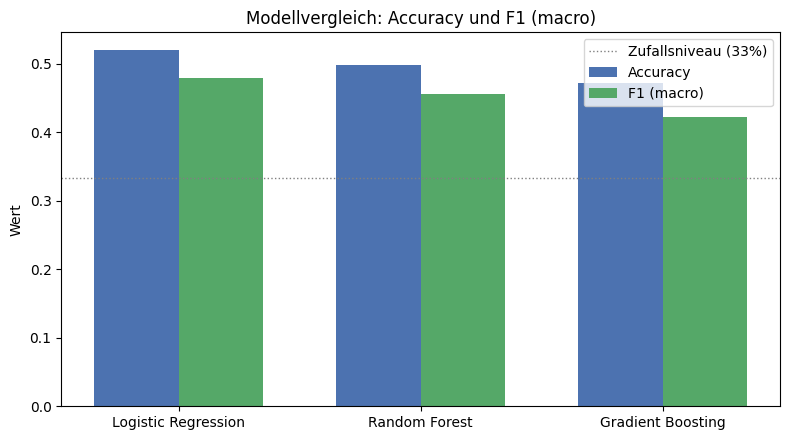

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

# Gleiche imputierten Trainings-/Testdaten wie beim Klassifikator oben (X_train_imp,
# X_test_imp, y_train, y_test), zusätzlich standardisiert (Random Forest selbst ist
# skaleninvariant - seine bereits oben berechnete Vorhersage y_pred bleibt identisch
# gültig, egal ob skaliert oder nicht)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_logreg = log_reg.predict(X_test_scaled)

grad_boost = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
grad_boost.fit(X_train_scaled, y_train)
y_pred_gb = grad_boost.predict(X_test_scaled)

predictions = {
    "Random Forest": y_pred,          # bereits oben (Abschnitt 5.1) berechnet
    "Logistic Regression": y_pred_logreg,
    "Gradient Boosting": y_pred_gb,
}

comparison_rows = []
for name, pred in predictions.items():
    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average="macro")
    comparison_rows.append({"Modell": name, "Accuracy": acc, "F1 (macro)": f1m})

comparison_df = pd.DataFrame(comparison_rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
display(comparison_df.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(comparison_df))
width = 0.35
ax.bar(x - width/2, comparison_df["Accuracy"], width, label="Accuracy", color="#4C72B0")
ax.bar(x + width/2, comparison_df["F1 (macro)"], width, label="F1 (macro)", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(comparison_df["Modell"])
ax.axhline(1/3, color="grey", linestyle=":", linewidth=1, label="Zufallsniveau (33%)")
ax.set_ylabel("Wert")
ax.set_title("Modellvergleich: Accuracy und F1 (macro)")
ax.legend()
plt.tight_layout()
plt.show()

#### **7.1 Confusion Matrices und Draw-Erkennung im Vergleich**

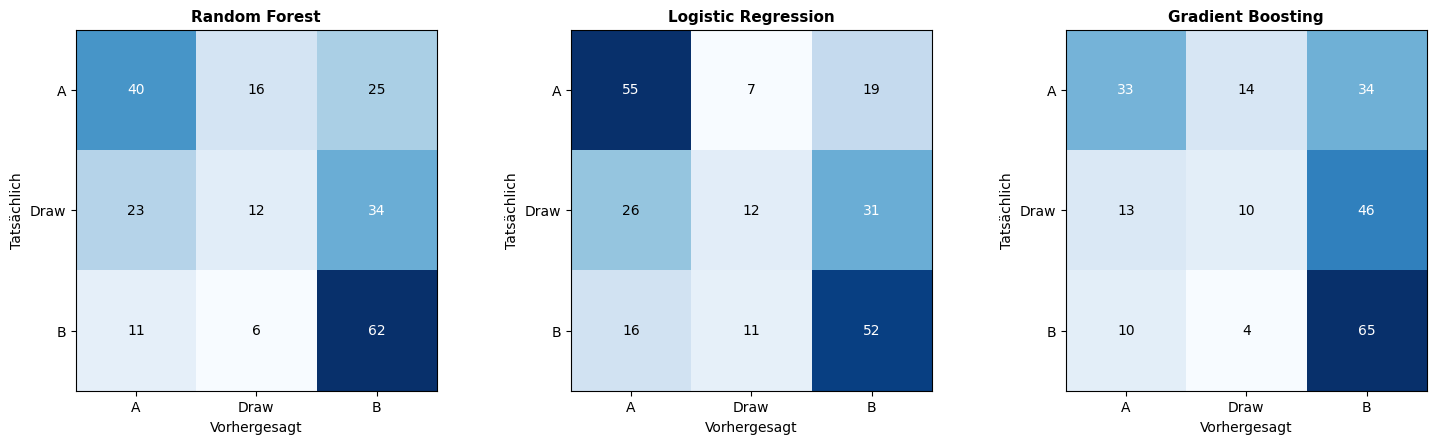

Draw-Recall pro Modell (Anteil der echten Unentschieden, die korrekt erkannt wurden):
  Random Forest          0.17
  Logistic Regression    0.17
  Gradient Boosting      0.14


In [11]:
model_names = list(predictions.keys())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, model_names):
    cm_i = confusion_matrix(y_test, predictions[name], labels=labels)
    im = ax.imshow(cm_i, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("Vorhergesagt"); ax.set_ylabel("Tatsächlich")
    ax.set_title(name, fontsize=11, fontweight="bold")
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm_i[i, j], ha="center", va="center",
                    color="white" if cm_i[i, j] > cm_i.max() / 2 else "black")
plt.tight_layout()
plt.show()

print("Draw-Recall pro Modell (Anteil der echten Unentschieden, die korrekt erkannt wurden):")
for name in model_names:
    cm_i = confusion_matrix(y_test, predictions[name], labels=labels)
    draw_idx = labels.index("Draw")
    draw_recall = cm_i[draw_idx, draw_idx] / cm_i[draw_idx].sum()
    print(f"  {name:<22} {draw_recall:.2f}")

#### **7.2 Fazit & Modellwahl**

**Ergebnis** (1'141 Spiele, Test: 229 Spiele ab 11.10.2024)

| Modell | Accuracy | F1 (macro) |
|---|---|---|
| Logistic Regression | 0.520 | 0.478 |
| Random Forest | 0.498 | 0.456 |
| Gradient Boosting | 0.472 | 0.423 |

Die Unterschiede zwischen den drei Modellen liegen bei nur
2-5 Prozentpunkten - bei einem Testset von 229 Spielen ist das eine Grössenordnung, die
gut innerhalb normaler Stichproben-Schwankung liegen kann. Es lässt sich also nicht klar
behaupten, ein Modell sei "wirklich besser" als ein anderes.

**Draw-Problem:** 
- Bei allen drei ähnlich schwach – strukturell bedingt (nicht modellabhängig)

**Entscheidung:** Random Forest bleibt Hauptmodell.
- Kein Modell klar überlegen → Genauigkeit allein kein Entscheidungskriterium
- Bereits vollständig integriert (Dashboard, Feature-Importance, Tore-Regressor)